In [1]:
#installing librarias
import pandas as pd

In [2]:
trxn= pd.read_csv('Retail_data_Transactions.csv')

In [3]:
trxn

,customer_id,trans_date,tran_amount
0,CS5295,11-Feb-13,35
1,CS4768,15-Mar-15,39
2,CS2122,26-Feb-13,52
3,CS1217,16-Nov-11,99
4,CS1850,20-Nov-13,78
...,...,...,...
124995,CS8433,26-Jun-11,64
124996,CS7232,19-Aug-14,38
124997,CS8731,28-Nov-14,42
124998,CS8133,14-Dec-13,13


In [4]:
response= pd.read_csv('Retail_Data_Response.csv')
response

FileNotFoundError: [Errno 2] No such file or directory: 'Retail_Data_Response.csv'

In [5]:
response= pd.read_csv('Retail_Data_Response.csv1')
response

FileNotFoundError: [Errno 2] No such file or directory: 'Retail_Data_Response.csv1'

In [6]:
response= pd.read_csv('Retail_Data_Response(2).csv')
response

FileNotFoundError: [Errno 2] No such file or directory: 'Retail_Data_Response(2).csv'

In [7]:
response= pd.read_csv('Retail_Data_Response.csv')
response

,customer_id,response
0,CS1112,0
1,CS1113,0
2,CS1114,1
3,CS1115,1
4,CS1116,1
...,...,...
6879,CS8996,0
6880,CS8997,0
6881,CS8998,0
6882,CS8999,0


In [8]:
df= trxn.merge(response, on='customer_id', how='left')
df

,customer_id,trans_date,tran_amount,response
0,CS5295,11-Feb-13,35,1.0
1,CS4768,15-Mar-15,39,1.0
2,CS2122,26-Feb-13,52,0.0
3,CS1217,16-Nov-11,99,0.0
4,CS1850,20-Nov-13,78,0.0
...,...,...,...,...
124995,CS8433,26-Jun-11,64,0.0
124996,CS7232,19-Aug-14,38,0.0
124997,CS8731,28-Nov-14,42,0.0
124998,CS8133,14-Dec-13,13,0.0


In [12]:
#features

df.dtypes
df.shape
df.head()
df.tail

<bound method NDFrame.tail of        customer_id trans_date  tran_amount  response
0           CS5295  11-Feb-13           35       1.0
1           CS4768  15-Mar-15           39       1.0
2           CS2122  26-Feb-13           52       0.0
3           CS1217  16-Nov-11           99       0.0
4           CS1850  20-Nov-13           78       0.0
...            ...        ...          ...       ...
124995      CS8433  26-Jun-11           64       0.0
124996      CS7232  19-Aug-14           38       0.0
124997      CS8731  28-Nov-14           42       0.0
124998      CS8133  14-Dec-13           13       0.0
124999      CS7996  13-Dec-14           36       0.0

[125000 rows x 4 columns]>

In [13]:
df.describe()

,tran_amount,response
count,125000.000000,124969.000000
mean,64.991912,0.110763
std,22.860006,0.313840
min,10.000000,0.000000
25%,47.000000,0.000000
50%,65.000000,0.000000
75%,83.000000,0.000000
max,105.000000,1.000000


In [14]:
# MISSING VALUES

df.isnull().sum()



customer_id     0
trans_date      0
tran_amount     0
response       31
dtype: int64

In [16]:
df=df.dropna()

In [17]:
df

,customer_id,trans_date,tran_amount,response
0,CS5295,11-Feb-13,35,1.0
1,CS4768,15-Mar-15,39,1.0
2,CS2122,26-Feb-13,52,0.0
3,CS1217,16-Nov-11,99,0.0
4,CS1850,20-Nov-13,78,0.0
...,...,...,...,...
124995,CS8433,26-Jun-11,64,0.0
124996,CS7232,19-Aug-14,38,0.0
124997,CS8731,28-Nov-14,42,0.0
124998,CS8133,14-Dec-13,13,0.0


In [18]:
set(df['response'])



{0.0, 1.0}

In [19]:
df.dtypes

customer_id     object
trans_date      object
tran_amount      int64
response       float64
dtype: object

In [31]:
# check for outliers
#Z-SCORE

from scipy import stats
import numpy as np

#calc z score
z_scores= np.abs(stats.zscore(df['tran_amount']))

#set a threshold

threshold= 3

outliers= z_scores > threshold

print(df[outliers])

Empty DataFrame
Columns: [customer_id, trans_date, tran_amount, response]
Index: []


In [32]:
# check for outliers
#Z-SCORE

from scipy import stats
import numpy as np

#calc z score
z_scores= np.abs(stats.zscore(df['response']))

#set a threshold

threshold= 3

outliers= z_scores>threshold

print(df[outliers])

Empty DataFrame
Columns: [customer_id, trans_date, tran_amount, response]
Index: []


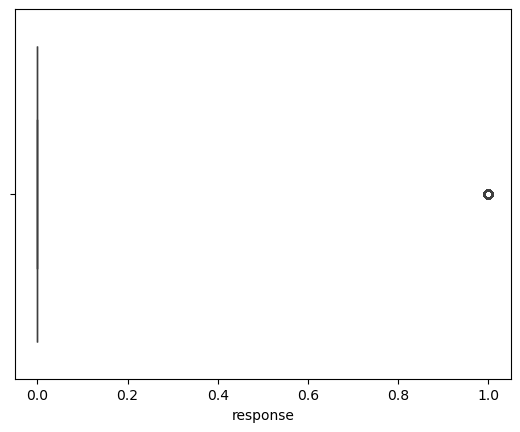

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['response'])
plt.show()

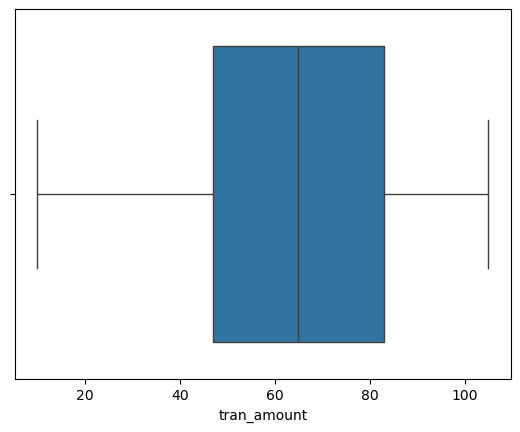

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['tran_amount'])
plt.show()

In [85]:
# creating new columns
 df.head()

IndentationError: unexpected indent (928940657.py, line 2)

In [87]:
df


,customer_id,trans_date,tran_amount,response,month
0,CS5295,2013-02-11,35,1.0,11-Feb-13
1,CS4768,2015-03-15,39,1.0,15-Mar-15
2,CS2122,2013-02-26,52,0.0,26-Feb-13
3,CS1217,2011-11-16,99,0.0,16-Nov-11
4,CS1850,2013-11-20,78,0.0,20-Nov-13
...,...,...,...,...,...
124995,CS8433,2011-06-26,64,0.0,26-Jun-11
124996,CS7232,2014-08-19,38,0.0,19-Aug-14
124997,CS8731,2014-11-28,42,0.0,28-Nov-14
124998,CS8133,2013-12-14,13,0.0,14-Dec-13


In [49]:
# which 3 months had the highest transaction amount?

monthly_Sales= df.groupby('month')['tran_amount'].sum()
monthly_Sales= monthly_Sales.sort_values(ascending=False).reset_index().head(3)
monthly_Sales 

,month,tran_amount
0,16-Jul-11,8791
1,20-May-14,8108
2,15-Nov-12,8054


In [55]:
# customers having highest num of orders
customer_counts= df['customer_id'].value_counts().reset_index()
customer_counts

# sort
top_5_cus= customer_counts.sort_values(by='count', ascending=False).head(5)
top_5_cus

,customer_id,count
0,CS4424,39
1,CS4320,38
2,CS3799,36
3,CS3013,35
4,CS1215,35


<Axes: xlabel='customer_id', ylabel='count'>

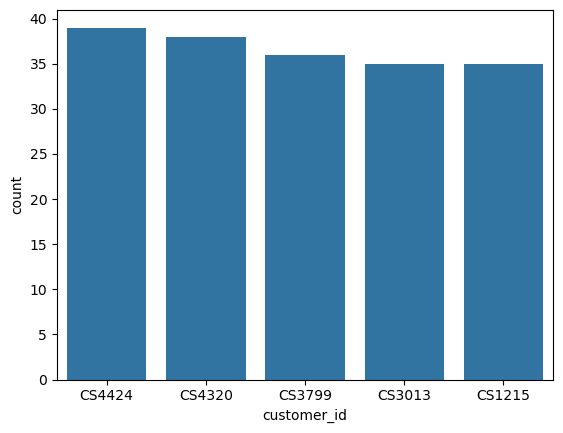

In [56]:
sns.barplot(x='customer_id',y='count',data=top_5_cus)

In [63]:
# customers having highest values of orders
customer_sales= df.groupby('customer_id')['tran_amount'].sum().reset_index()
customer_sales

# sort

# top_5_cus= customer_counts.sort_volumns(by='count',ascending=False).head(5)
#top_5_cus


,customer_id,tran_amount
0,CS1112,1012
1,CS1113,1490
2,CS1114,1432
3,CS1115,1659
4,CS1116,857
...,...,...
6879,CS8996,582
6880,CS8997,543
6881,CS8998,624
6882,CS8999,383


In [62]:
# customers having highest values of orders
customer_sales= df.groupby('customer_id')['tran_amount'].sum().reset_index()
customer_sales

# sort

top_5_sal= customer_sales.sort_values(by='tran_amount',ascending=False).head(5)
top_5_sal


,customer_id,tran_amount
3312,CS4424,2933
3208,CS4320,2647
4640,CS5752,2612
3548,CS4660,2527
2687,CS3799,2513


<Axes: xlabel='customer_id', ylabel='tran_amount'>

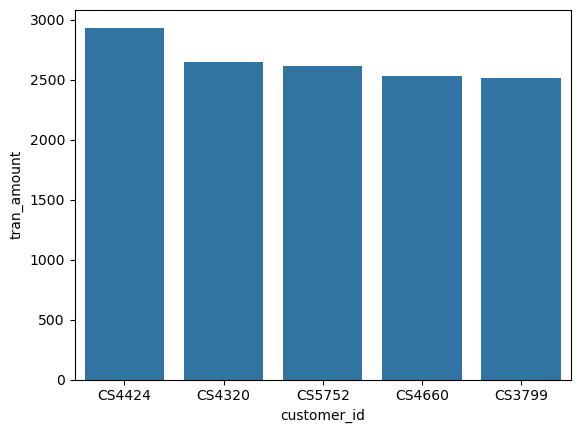

In [64]:
sns.barplot(x='customer_id',y='tran_amount',data=top_5_sal)

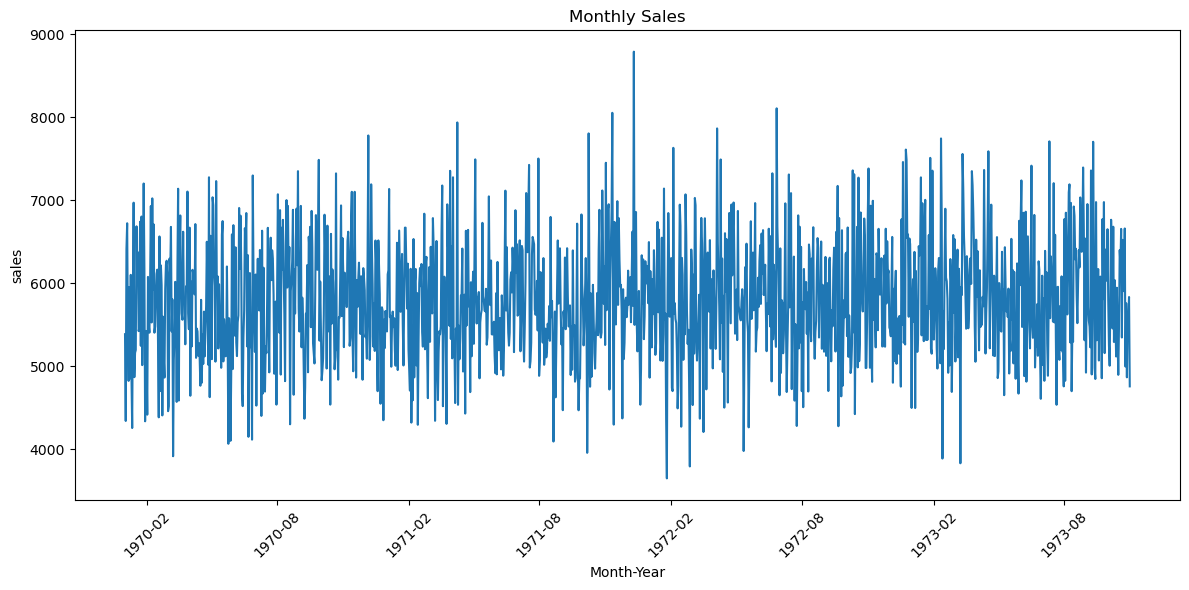

In [112]:
df = df.copy()

df['trans_date'] = pd.to_datetime(df['trans_date'], errors='coerce')
df['month_year'] = df['trans_date'].dt.strftime('%Y-%m')

plt.figure(figsize=(12,6))
plt.plot(monthly_sales.index,monthly_sales.values)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xlabel('Month-Year')
plt.ylabel('sales')
plt.title('Monthly Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
                                                         




In [105]:
df

,customer_id,trans_date,tran_amount,response,month,month_year
0,CS5295,2013-02-11,35,1.0,11-Feb-13,2013-02
1,CS4768,2015-03-15,39,1.0,15-Mar-15,2015-03
2,CS2122,2013-02-26,52,0.0,26-Feb-13,2013-02
3,CS1217,2011-11-16,99,0.0,16-Nov-11,2011-11
4,CS1850,2013-11-20,78,0.0,20-Nov-13,2013-11
...,...,...,...,...,...,...
124995,CS8433,2011-06-26,64,0.0,26-Jun-11,2011-06
124996,CS7232,2014-08-19,38,0.0,19-Aug-14,2014-08
124997,CS8731,2014-11-28,42,0.0,28-Nov-14,2014-11
124998,CS8133,2013-12-14,13,0.0,14-Dec-13,2013-12


In [113]:
# Recency
recency= df.groupby('customer_id')['trans_date'].max()

# Frequency

frequency= df.groupby('customer_id')['trans_date'].count()

# Monetory

monetary= df.groupby('customer_id')['tran_amount'].sum()

# Combine

rfm= pd.DataFrame({'recently':recency, 'frequency':frequency,'monetary':monetary})

In [114]:
rfm

,recently,frequency,monetary
customer_id,,,
CS1112,2015-01-14,15,1012
CS1113,2015-02-09,20,1490
CS1114,2015-02-12,19,1432
CS1115,2015-03-05,22,1659
CS1116,2014-08-25,13,857
...,...,...,...
CS8996,2014-12-09,13,582
CS8997,2014-06-28,14,543
CS8998,2014-12-22,13,624


In [121]:
# customer segmentation

def segment_customer(row):
    if row['recently'].year>2012 and row['frequency']>=15 and row['monetary']>1000:
        return 'P0'
    elif (2011<=row['recently'].year<2012) and (10<row['frequency']<15) and (500<=row['monetary']<=1000):
        return 'P1'
    else:
        return 'P2'
rfm['segment']= rfm.apply(segment_customer, axis=1)        
        

In [122]:
rfm

,recently,frequency,monetary,segment
customer_id,,,,
CS1112,2015-01-14,15,1012,P0
CS1113,2015-02-09,20,1490,P0
CS1114,2015-02-12,19,1432,P0
CS1115,2015-03-05,22,1659,P0
CS1116,2014-08-25,13,857,P2
...,...,...,...,...
CS8996,2014-12-09,13,582,P2
CS8997,2014-06-28,14,543,P2
CS8998,2014-12-22,13,624,P2


<Axes: xlabel='response'>

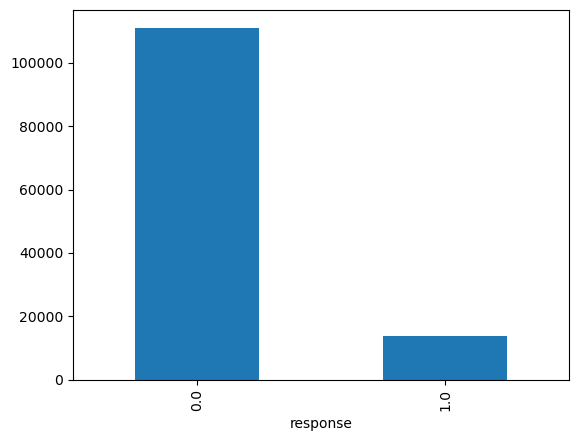

In [124]:
# count the numbers of churned and active customers
churn_counts= df['response']. value_counts()

#plot
churn_counts.plot(kind='bar')

<Axes: xlabel='month_year'>

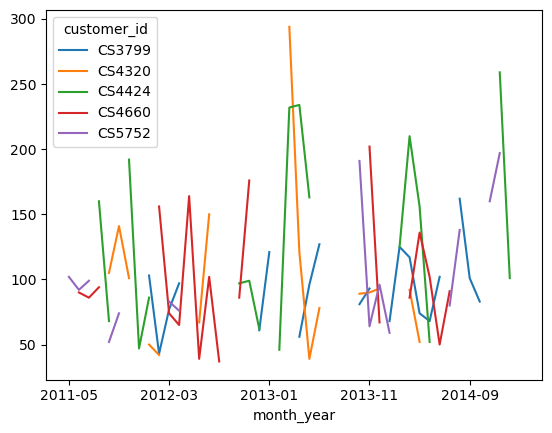

In [128]:
top_5_cus = monetary.sort_values(ascending=False).head(5).index

top_customer_df = df[df['customer_id'].isin(top_5_cus)]

top_customer_sales = top_customer_df.groupby(
    ['customer_id', 'month_year']
)['tran_amount'].sum().unstack(level=0)

top_customer_sales.plot(kind='line')

In [129]:
df

,customer_id,trans_date,tran_amount,response,month,month_year
0,CS5295,2013-02-11,35,1.0,11-Feb-13,2013-02
1,CS4768,2015-03-15,39,1.0,15-Mar-15,2015-03
2,CS2122,2013-02-26,52,0.0,26-Feb-13,2013-02
3,CS1217,2011-11-16,99,0.0,16-Nov-11,2011-11
4,CS1850,2013-11-20,78,0.0,20-Nov-13,2013-11
...,...,...,...,...,...,...
124995,CS8433,2011-06-26,64,0.0,26-Jun-11,2011-06
124996,CS7232,2014-08-19,38,0.0,19-Aug-14,2014-08
124997,CS8731,2014-11-28,42,0.0,28-Nov-14,2014-11
124998,CS8133,2013-12-14,13,0.0,14-Dec-13,2013-12


In [130]:
df.to_csv('MainData.csv')

In [131]:
rfm.to_csv('AddAnlys.csv')